# Real-data robustness study: one figure per property

Reads `results/real_robustness/` produced by

```bash
python run_real_data.py --study robustness --sweep all --seeds 0:50 --workers 12
python run_real_data.py --study robustness --clean-fit   # judge-level position effects (main figure, panel d)
```

Design: `code/plan/2026-09-06-real-data-robustness-plan.md` (Section 22) and `2026-09-07-real-data-presentation-plan.md` (Section 9). Metric: excess held-out human log loss over the test-pool BTL floor (continuous, comparable across the three benchmarks) and, on Chatbot Arena only, Kendall $\tau$ with the held-out human ranking (MT-Bench and PandaLM have 15 and 10 pairs, so $\tau$ moves in steps of 0.13 and 0.2 and saturates). Bars and bands are $\pm1.96$ Monte Carlo s.e. over seeds.
Methods: Human-only; Pooled-LLM (no judge structure, no order term, scale calibrated); Consensus-cal (two-step, $s=\alpha\widehat\mu$); DIAL ($\mu$ aligned to the human comparisons, $V$ on the LLM side, GACV weight); DIAL-noDeb (DIAL without the order term). DIAL-W and the fixed-weight variants are appendix diagnostics.

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

REPO = Path.cwd().parent; sys.path.insert(0, str(REPO))
from experiments.real_data.robustness_plot import load, aggregate, aggregate_spectest
RESULTS = REPO / "results" / "real_robustness"; FIGURES = REPO / "figures"; FIGURES.mkdir(exist_ok=True)
DATASETS = ["arena_33k", "mt_bench", "pandalm"]; DLAB = {"arena_33k": "Chatbot Arena", "mt_bench": "MT-Bench", "pandalm": "PandaLM"}
# Shared method panel (experiments/style.py): five presented methods plus appendix diagnostics.
from experiments.style import PRESENTED, APPENDIX, LABEL as _LABEL, STYLE as _STYLE, INK, INK_SOFT, GRID
METHODS = list(PRESENTED)
LABEL = dict(_LABEL); LABEL["oracle_test"] = "test-oracle weight"
STYLE = dict(_STYLE); STYLE["oracle_test"] = dict(STYLE["oracle"])
mpl.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman", "Nimbus Roman", "DejaVu Serif"], "font.size": 8, "axes.labelsize": 8.5,
                     "axes.titlesize": 9, "xtick.labelsize": 7.5, "ytick.labelsize": 7.5, "legend.fontsize": 7.5, "axes.edgecolor": INK_SOFT,
                     "axes.linewidth": 0.6, "pdf.fonttype": 42, "ps.fonttype": 42, "savefig.dpi": 300, "figure.dpi": 130})

rows = {d: load(d, REPO) for d in DATASETS if (RESULTS / d / "rows.jsonl").exists()}
agg = {d: aggregate(df) for d, df in rows.items()}
spec = aggregate_spectest(rows["arena_33k"]) if "arena_33k" in rows else pd.DataFrame()
for d, df in rows.items():
    ok = df[(~df.failed) & (~df.method.isin(["spectest", "planner"]))]
    print(f"{DLAB[d]:<14} seeds={df.seed.nunique()}  rows={len(df)}  failed={int(df.failed.sum())}  non-converged={int((~ok.converged.fillna(True).astype(bool)).sum())}")
if any(rows[d].failed.any() for d in rows):
    print(pd.concat(rows.values())[lambda x: x.failed].groupby(["dataset", "sweep", "panel", "level", "method"]).size().to_string())

Chatbot Arena  seeds=50  rows=31080  failed=70  non-converged=2023
MT-Bench       seeds=50  rows=24005  failed=276  non-converged=3353
PandaLM        seeds=50  rows=23827  failed=420  non-converged=3308
dataset    sweep         panel    level   method       
arena_33k  llm_budget    all      500.0   dial_mu           1
                                          dial_nodeb       11
                                          dial_w            2
                                  1000.0  consensus_cal     4
                                          dial_nodeb        5
                                          dial_w            5
                                  2000.0  consensus_cal     2
                                          dial_w            2
           noise         biased5  4.0     consensus_cal     6
                                          dial_nodeb       17
                                          dial_w            6
                                  8.0     consensus_cal    

In [2]:
def curve(ax, a, sweep, panel, kind, methods, x="level", n_0_level=None, logx=False, hline_human=True, band=True, metric="excess"):
    g = a[(a.sweep == sweep) & (a.panel == panel) & (a.kind == kind)]
    if n_0_level is not None: g = g[g.n_0_level == n_0_level]
    if g.empty: ax.text(0.5, 0.5, "not run", ha="center", va="center", transform=ax.transAxes, color=INK_SOFT); return
    for m in methods:
        gm = g[g.method == m].copy()
        if gm.empty: continue
        gm["_x"] = gm["n_0_mean"] if x == "n_0" else gm["level"]
        gm = gm.sort_values("_x")
        xs = gm["_x"].to_numpy()
        y = gm[f"{metric}_mean"].to_numpy(); se = gm[f"{metric}_se"].to_numpy()
        st = dict(STYLE[m]); lw = st.pop("lw", 1.2); mk = st.pop("marker")
        if m == "human_only" and hline_human and x != "n_0":
            ax.axhline(y.mean(), color=st["color"], ls="-", lw=1.0, label=LABEL[m]); continue
        ax.plot(xs, y, lw=lw, marker=mk, ms=3.2, label=LABEL[m], **st)
        if band and m != "human_only": ax.fill_between(xs, y - 1.96 * se, y + 1.96 * se, color=st["color"], alpha=0.10, lw=0)
    if logx: ax.set_xscale("log"); ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    ax.grid(True, color=GRID, lw=0.5); ax.tick_params(length=2.5)

def clip_axis(ax, a, sweep, panel, kind, methods, n_0_level=None, top=None):
    g = a[(a.sweep == sweep) & (a.panel == panel) & (a.kind == kind) & (a.method.isin(methods))]
    if n_0_level is not None: g = g[g.n_0_level == n_0_level]
    lo = g.excess_mean.min(); hi = g.excess_mean.max() if top is None else min(g.excess_mean.max(), lo + top)
    ax.set_ylim(lo - 0.15 * (hi - lo), hi + 0.1 * (hi - lo))

BAR_METHODS = ["pooled_cal", "consensus_cal", "dial_mu", "dial_nodeb"]

def cell_of(a, q):
    g = a[(a.sweep == q["sweep"]) & (a.panel == q["panel"]) & (a.kind == q["kind"]) & np.isclose(a.level, q["level"])]
    if q.get("n_0_level") is not None: g = g[g.n_0_level == q["n_0_level"]]
    return g

def bar_panel(ax, a, specs, methods=BAR_METHODS, metric="excess", human=True, legend=False):
    """Grouped bars: one group per level in `specs` (label, query), one bar per method; human-only as a line."""
    width = 0.8 / len(methods); xs = np.arange(len(specs)); hvals = []
    for i, (lab, q) in enumerate(specs):
        g = cell_of(a, q)
        for j, m in enumerate(methods):
            gm = g[g.method == m]
            if gm.empty: continue
            y = float(gm[f"{metric}_mean"].iloc[0]); se = float(gm[f"{metric}_se"].iloc[0])
            ax.bar(xs[i] + (j - (len(methods) - 1) / 2) * width, y, width * 0.9, color=STYLE[m]["color"], label=LABEL[m] if i == 0 else None,
                   yerr=1.96 * se, error_kw=dict(lw=0.6, capsize=1.5, ecolor=INK), zorder=2)
        gh = g[g.method == "human_only"]
        if not gh.empty: hvals.append(float(gh[f"{metric}_mean"].iloc[0]))
    if human and hvals: ax.axhline(np.mean(hvals), color=STYLE["human_only"]["color"], lw=1.0, label=LABEL["human_only"], zorder=1)
    ax.set_xticks(xs); ax.set_xticklabels([l for l, _ in specs], fontsize=7); ax.set_xlim(-0.55, len(specs) - 0.45)
    ax.grid(True, axis="y", color=GRID, lw=0.5); ax.tick_params(length=2.5); ax.set_axisbelow(True)
    if legend: ax.legend(frameon=False, fontsize=6.5)

# the three levels of each main-figure row, per dataset (biased-five panel throughout)
N0_ABUNDANT = {"arena_33k": 300, "mt_bench": 80, "pandalm": 60}          # default calibration size (order and abundant-injection sweeps)
N0_SCARCE = {"arena_33k": 1000, "mt_bench": 80, "pandalm": 60}           # noise_scarce n_0_fixed and the llm_budget n_0 level used
NL_ABUNDANT = {"arena_33k": 20000, "mt_bench": 1600, "pandalm": 1000}    # largest llm_budget level
NL_SCARCE = {"arena_33k": 2000, "mt_bench": 160, "pandalm": 100}         # noise_scarce base sample (about ten judgments per pair)

def row1_specs(d):
    return [("balanced", dict(sweep="order", panel="biased5", kind="none", level=1.0)),
            ("one-sided", dict(sweep="order", panel="biased5", kind="none", level=0.05)),
            ("one-sided\n+8 position judges", dict(sweep="noise", panel="biased5", kind="position", level=8))]

def row2_specs(d):
    return [(f"abundant\n$n_L$={NL_ABUNDANT[d]:,}", dict(sweep="llm_budget", panel="biased5", kind="none", level=NL_ABUNDANT[d], n_0_level=N0_SCARCE[d])),
            (f"scarce\n$n_L$={NL_SCARCE[d]:,}", dict(sweep="noise_scarce", panel="biased5", kind="anti", level=0)),
            ("scarce\n+4 anti-consensus", dict(sweep="noise_scarce", panel="biased5", kind="anti", level=4))]


## Main-text figure (2 x 4)

Columns 1 to 3: Chatbot Arena, MT-Bench, PandaLM, with the five position-sensitive judges; grouped bars over three levels, excess held-out log loss, human-only BTL as a line.
Row 1, position debiasing: balanced display; one-sided display (5% swapped copies); one-sided display plus 8 injected position-only judges. Pooled-LLM and DIAL-noDeb rise, DIAL and Consensus-cal do not.
Row 2, adaptive weighting and robustness: abundant LLM data (largest $n_L$ level); scarce LLM data (about ten judgments per pair); scarce plus 4 injected anti-consensus judges. DIAL equals Consensus-cal when abundant, beats it when scarce, and holds when the LLM panel is corrupted.
Column 4: judge-level position effects on the three datasets (row 1) and the specification test of $s_0=\alpha\mu$ on Chatbot Arena, the only benchmark with a covariate that defines a subpopulation (row 2).

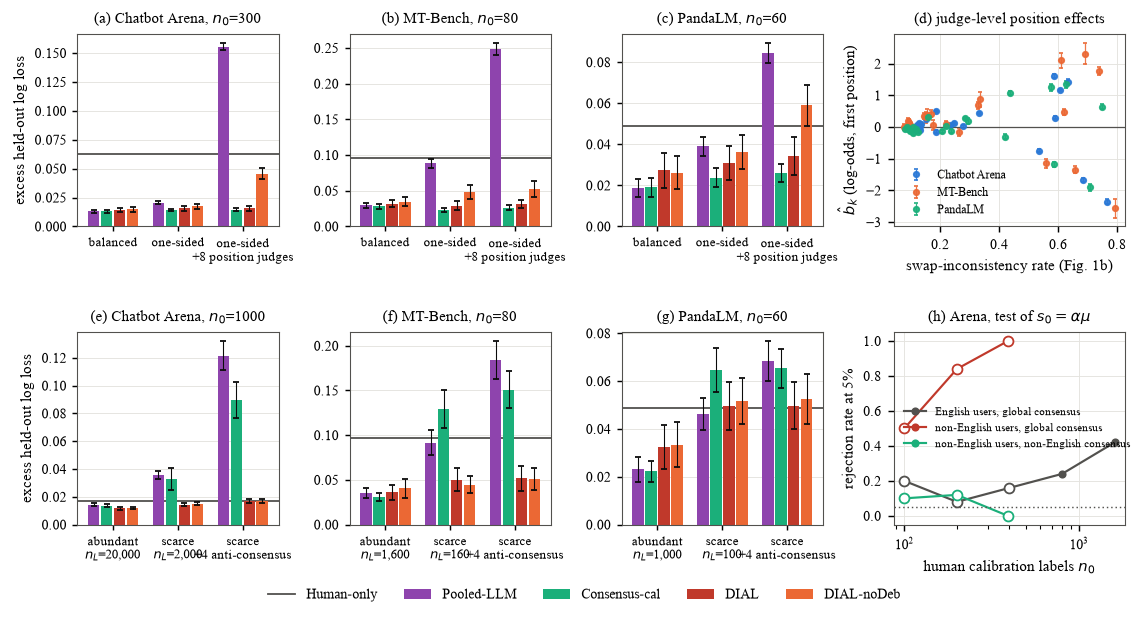

n Human-only  \
dataset       row       level                                         
Chatbot Arena position  balanced                      50     0.0625   
                        one-sided                     50     0.0625   
                        one-sided +8 position judges  50     0.0625   
              weighting abundant $n_L$=20,000         50     0.0169   
                        scarce $n_L$=2,000            50     0.0169   
                        scarce +4 anti-consensus      50     0.0169   
MT-Bench      position  balanced                      50     0.0966   
                        one-sided                     50     0.0966   
                        one-sided +8 position judges  50     0.0966   
              weighting abundant $n_L$=1,600          50     0.0966   
                        scarce $n_L$=160              50     0.0966   
                        scarce +4 anti-consensus      50     0.0966   
PandaLM       position  balanced                      50     0.0489   
                        one-sided                     50     0.0489   
                        one-sided +8 position judges  50     0.0489   
              weighting abundant $n_L$=1,000          50     0.0489   
                        scarce $n_L$=100              50     0.0489   
                        scarce +4 anti-consensus      50     0.0489   

                                                     Pooled-LLM Consensus-cal  \
dataset       row       level                                                   
Chatbot Arena position  balanced                         0.0131        0.0131   
                        one-sided                        0.0205        0.0142   
                        one-sided +8 position judges     0.1555        0.0145   
              weighting abundant $n_L$=20,000            0.0143        0.0135   
                        scarce $n_L$=2,000               0.0360        0.0328   
                        scarce +4 anti-consensus         0.1214        0.0897   
MT-Bench      position  balanced                         0.0296        0.0285   
                        one-sided                        0.0883        0.0235   
                        one-sided +8 position judges     0.2483        0.0264   
              weighting abundant $n_L$=1,600             0.0352        0.0309   
                        scarce $n_L$=160                 0.0918        0.1295   
                        scarce +4 anti-consensus         0.1838        0.1510   
PandaLM       position  balanced                         0.0189        0.0190   
                        one-sided                        0.0390        0.0238   
                        one-sided +8 position judges     0.0844        0.0260   
              weighting abundant $n_L$=1,000             0.0232        0.0222   
                        scarce $n_L$=100                 0.0463        0.0646   
                        scarce +4 anti-consensus         0.0683        0.0653   

                                                        DIAL DIAL-noDeb  
dataset       row       level                                            
Chatbot Arena position  balanced                      0.0145     0.0147  
                        one-sided                     0.0158     0.0173  
                        one-sided +8 position judges  0.0158     0.0457  
              weighting abundant $n_L$=20,000         0.0118     0.0118  
                        scarce $n_L$=2,000            0.0144     0.0151  
                        scarce +4 anti-consensus      0.0169     0.0169  
MT-Bench      position  balanced                      0.0320     0.0346  
                        one-sided                     0.0287     0.0488  
                        one-sided +8 position judges  0.0316     0.0525  
              weighting abundant $n_L$=1,600          0.0359     0.0405  
                        scarce $n_L$=160              0.0504     0.0444  
                        scarce +4 anti-consensus   

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(10.4, 4.9), gridspec_kw=dict(width_ratios=[1, 1, 1, 1.15], wspace=0.34, hspace=0.55))
for j, d in enumerate(DATASETS):
    if d in agg:
        bar_panel(axes[0, j], agg[d], row1_specs(d)); bar_panel(axes[1, j], agg[d], row2_specs(d))
    axes[0, j].set_title(f"({'abc'[j]}) {DLAB[d]}, $n_0$={N0_ABUNDANT[d]}", fontsize=8.5)
    axes[1, j].set_title(f"({'efg'[j]}) {DLAB[d]}, $n_0$={N0_SCARCE[d]}", fontsize=8.5)
axes[0, 0].set_ylabel("excess held-out log loss"); axes[1, 0].set_ylabel("excess held-out log loss")
# (d) judge-level position effects
ax = axes[0, 3]; col3 = {"arena_33k": "#2a78d6", "mt_bench": "#eb6834", "pandalm": "#1baf7a"}
for d in DATASETS:
    cf = RESULTS / d / "clean_fit.json"; runs = sorted((REPO / "results" / "motivation").glob(f"{d}-*"))
    if not cf.exists() or not runs: continue
    f = json.load(open(cf)); mot = pd.read_csv(runs[-1] / "per_judge.csv").set_index("judge")
    x = np.array([mot.loc[j, "swap_inconsistency_rate"] if j in mot.index else np.nan for j in f["judges"]]); b = np.array(f["b"]); lo = np.array(f["b_lower"]); hi = np.array(f["b_upper"])
    ax.errorbar(x, b, yerr=[b - lo, hi - b], fmt="o", ms=3, lw=0.7, capsize=1.2, color=col3[d], label=DLAB[d], alpha=0.9)
ax.axhline(0, color=INK_SOFT, lw=0.7); ax.set_xlabel("swap-inconsistency rate (Fig. 1b)"); ax.set_ylabel("$\\hat b_k$ (log-odds, first position)"); ax.set_title("(d) judge-level position effects", fontsize=8.5)
ax.grid(True, color=GRID, lw=0.5); ax.legend(frameon=False, fontsize=6.5)
# (h) specification test
ax = axes[1, 3]
if not spec.empty:
    scol = {"english_global": ("#52514e", "English users, global consensus"), "nonenglish_global": ("#c0392b", "non-English users, global consensus"), "nonenglish_subset": ("#1baf7a", "non-English users, non-English consensus")}
    for k, (c, lab) in scol.items():
        g = spec[spec.kind == k].sort_values("n_0").drop_duplicates("n_0")
        ax.plot(g.n_0, g.reject_rate, color=c, marker="o", ms=3.5, lw=1.2, label=lab)
        bad = g[g.ho_exists < 1]; ax.scatter(bad.n_0, bad.reject_rate, s=30, facecolors="white", edgecolors=c, zorder=3)
    ax.axhline(0.05, color=INK_SOFT, ls=(0, (1, 2)), lw=0.8); ax.set_xscale("log"); ax.set_ylim(-0.05, 1.05); ax.set_xlabel("human calibration labels $n_0$"); ax.set_ylabel("rejection rate at 5%")
    ax.set_title("(h) Arena, test of $s_0=\\alpha\\mu$", fontsize=8.5); ax.legend(frameon=False, fontsize=6.2, loc="center left"); ax.grid(True, color=GRID, lw=0.5)
h, l = axes[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.savefig(FIGURES / "fig_real_main.pdf", bbox_inches="tight"); plt.show()
# numbers behind the bars
tab = []
for d in DATASETS:
    if d not in agg: continue
    for row, specs in (("position", row1_specs(d)), ("weighting", row2_specs(d))):
        for lab, q in specs:
            g = cell_of(agg[d], q)
            tab.append(dict(dataset=DLAB[d], row=row, level=lab.replace("\n", " "), n=int(g.n.max()) if len(g) else 0, **{LABEL[m]: f"{g[g.method == m].excess_mean.iloc[0]:.4f}" if (g.method == m).any() else "" for m in ["human_only"] + BAR_METHODS}))
display(pd.DataFrame(tab).set_index(["dataset", "row", "level"]))

## Appendix figure: the curves behind the bars (Chatbot Arena)

Top row, excess held-out log loss: (a) swapped-copy share $\rho_{\mathrm{swap}}$ (five judges, $n_0=300$); (b) injected position-only judges with abundant LLM data; (c) injected anti-consensus judges in the scarce regime.
Bottom row, Kendall $\tau$ with the held-out human ranking: (d) injected position-only judges, abundant; (e) LLM comparisons $n_L$ (five judges, $n_0=1{,}000$); (f) injected anti-consensus judges, scarce.

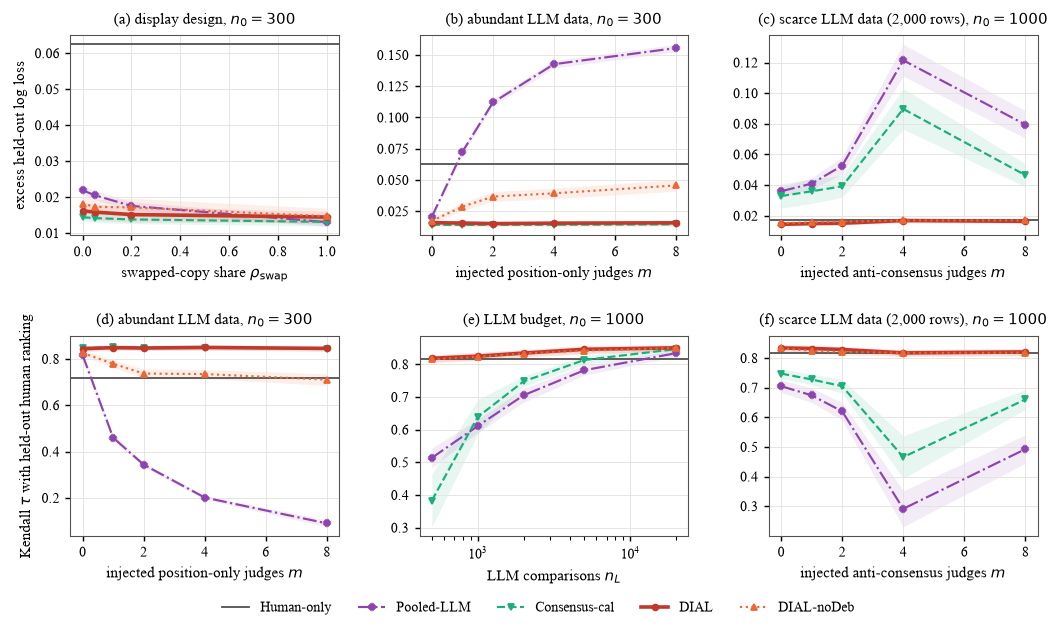

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(9.6, 5.0), gridspec_kw=dict(hspace=0.5, wspace=0.3))
if "arena_33k" in agg:
    a = agg["arena_33k"]
    curve(axes[0, 0], a, "order", "biased5", "none", PRESENTED); axes[0, 0].set_xlabel("swapped-copy share $\\rho_{\\mathrm{swap}}$"); axes[0, 0].set_title("(a) display design, $n_0=300$", fontsize=8.5)
    curve(axes[0, 1], a, "noise", "biased5", "position", PRESENTED); axes[0, 1].set_xlabel("injected position-only judges $m$"); axes[0, 1].set_title("(b) abundant LLM data, $n_0=300$", fontsize=8.5)
    curve(axes[0, 2], a, "noise_scarce", "biased5", "anti", PRESENTED); axes[0, 2].set_xlabel("injected anti-consensus judges $m$"); axes[0, 2].set_title("(c) scarce LLM data (2,000 rows), $n_0=1000$", fontsize=8.5)
    curve(axes[1, 0], a, "noise", "biased5", "position", PRESENTED, metric="ref_kendall"); axes[1, 0].set_xlabel("injected position-only judges $m$"); axes[1, 0].set_title("(d) abundant LLM data, $n_0=300$", fontsize=8.5)
    curve(axes[1, 1], a, "llm_budget", "biased5", "none", PRESENTED, n_0_level=1000, logx=True, metric="ref_kendall"); axes[1, 1].set_xlabel("LLM comparisons $n_L$"); axes[1, 1].set_title("(e) LLM budget, $n_0=1000$", fontsize=8.5)
    curve(axes[1, 2], a, "noise_scarce", "biased5", "anti", PRESENTED, metric="ref_kendall"); axes[1, 2].set_xlabel("injected anti-consensus judges $m$"); axes[1, 2].set_title("(f) scarce LLM data (2,000 rows), $n_0=1000$", fontsize=8.5)
axes[0, 0].set_ylabel("excess held-out log loss"); axes[1, 0].set_ylabel("Kendall $\\tau$ with held-out human ranking")
h, l = axes[0, 0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.savefig(FIGURES / "fig_real_curves.pdf", bbox_inches="tight"); plt.show()

## Appendix figure: human-record efficiency

Top: human budget with the as-collected balanced LLM data (all 21 judges); the LLM-anchored estimators sit at the LLM floor from a few hundred labels while human-only needs the full pool. Human-only is off the chart at the smallest budgets, where its MLE does not exist.
Bottom: LLM rows of the five position-sensitive judges subsampled to $n_L$ at a fixed human budget, on the three benchmarks; with ten or fewer judgments per pair DIAL beats both the two-step consensus calibration and human-only. Dotted: the weight minimizing the test log loss.

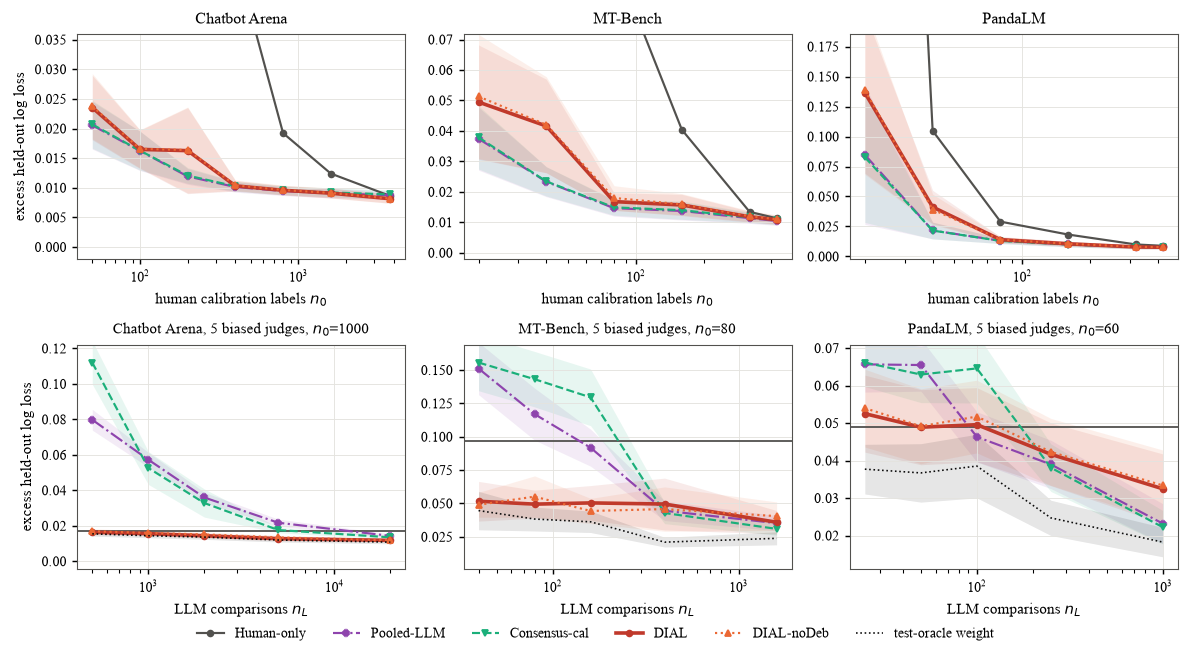

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(9.2, 4.9))
methods_C1 = list(PRESENTED)
for ax, d in zip(axes[0], DATASETS):
    if d in agg:
        curve(ax, agg[d], "budget", "all", "none", methods_C1, x="n_0", logx=True, hline_human=False)
        g = agg[d][(agg[d].sweep == "budget") & (agg[d].method != "human_only") & (agg[d].method.isin(methods_C1))]
        ax.set_ylim(min(g.excess_mean.min(), g.floor.mean() * 0) - 0.002, g.excess_mean.max() * 1.3 + 0.005)
    ax.set_title(DLAB[d]); ax.set_xlabel("human calibration labels $n_0$")
axes[0, 0].set_ylabel("excess held-out log loss")
methods_C2 = list(PRESENTED) + ["oracle_test"]
for ax, d in zip(axes[1], DATASETS):
    if d in agg:
        curve(ax, agg[d], "llm_budget", "biased5", "none", methods_C2, n_0_level=N0_SCARCE[d], logx=True); clip_axis(ax, agg[d], "llm_budget", "biased5", "none", methods_C2, n_0_level=N0_SCARCE[d])
    ax.set_title(f"{DLAB[d]}, 5 biased judges, $n_0$={N0_SCARCE[d]}", fontsize=8.5); ax.set_xlabel("LLM comparisons $n_L$")
axes[1, 0].set_ylabel("excess held-out log loss")
h1, l1 = axes[0, 0].get_legend_handles_labels(); h2, l2 = axes[1, 0].get_legend_handles_labels()
seen = {}; [seen.setdefault(l, h) for h, l in list(zip(h1, l1)) + list(zip(h2, l2))]
fig.legend(list(seen.values()), list(seen.keys()), loc="lower center", ncol=8, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.tight_layout(); fig.savefig(FIGURES / "fig_real_efficiency.pdf", bbox_inches="tight"); plt.show()

## Appendix figure: budget planning from a pilot

From a pilot of $n_{\mathrm{pilot}}$ human labels, the specification-test statistic $T$ gives the point estimate $\widehat\Delta = \max\{0, (T - \mathrm{df})/(2n_{\mathrm{pilot}})\}$ and, by inverting the noncentral $\chi^2_{\mathrm{df}}$ distribution of $T$, a two-sided 90% interval $[\widehat\Delta_{\mathrm{lo}}, \widehat\Delta_{\mathrm{hi}}]$ for the anchor's misspecification $\Delta_W$.
Predicted excess (relative to the in-sample test-pool floor, whose optimism $(N-1)/(2n_{\mathrm{test}})$ is added back): anchored $\Delta + (r+1)/(2n)$ at the point estimate (line) and at the two interval ends (band); human-only $(N-1)/(2n)$; the crossover $n^\star=(N-r-2)/(2\Delta)$ is drawn at the point estimate (dashed) and as the interval implied by $[\widehat\Delta_{\mathrm{lo}}, \widehat\Delta_{\mathrm{hi}}]$ (grey span, open to the right when the lower end is zero).
All quantities are medians over the 50 pilots; the mean gives interval ends within 0.002 of the median ends, so the choice of aggregate no longer matters once the interval replaces the point estimate.
Observed curves are the 50-seed `budget` sweep (Consensus-cal and human-only).

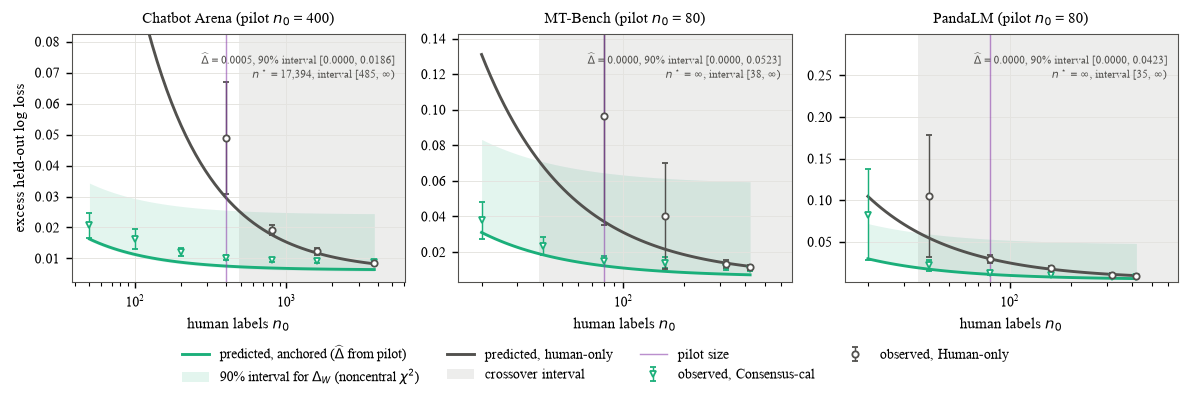

,dataset,n_pilot,delta_hat_median,delta_lo_median,delta_hi_median,delta_hat_mean,delta_lo_mean,delta_hi_mean,delta_all_train,n_star_point,n_star_interval_lo,n_star_interval_hi,n_star_observed,share_pilots_delta_zero,share_pilots_interval_lo_zero,coverage_of_fullpool
0,Chatbot Arena,400,0.0005,0.0,0.0186,0.0043,0.0005,0.0197,0.0013,17394.0757,484.8452,inf,3556.8511,0.46,0.88,0.88
1,MT-Bench,80,0.0000,0.0,0.0523,0.0065,0.0003,0.0542,0.0000,inf,38.2414,inf,NaN,0.54,0.96,0.96
2,PandaLM,80,0.0000,0.0,0.0423,0.0038,0.0001,0.0433,0.0000,inf,35.4775,inf,NaN,0.64,0.98,0.98


,dataset,n_pilot,delta_hat_median,delta_hat_q10,delta_hat_q90,n_star_median,labels_to_eps_anchored_median,labels_to_eps_human_only,eps
0,Chatbot Arena,100,0.0171,0.0,0.0470,410.1687,inf,950.0,0.01
1,Chatbot Arena,200,0.0058,0.0,0.0361,724.5055,120.4057,950.0,0.01
2,Chatbot Arena,400,0.0005,0.0,0.0140,1648.8709,52.7817,950.0,0.01
3,MT-Bench,40,0.0105,0.0,0.0551,64.0439,inf,250.0,0.01
4,MT-Bench,80,0.0000,0.0,0.0210,208.4971,50.0000,250.0,0.01
5,MT-Bench,160,0.0000,0.0,0.0183,186.6898,50.0000,250.0,0.01
6,PandaLM,40,0.0000,0.0,0.0622,45.4733,50.0000,200.0,0.01
7,PandaLM,80,0.0000,0.0,0.0148,212.0522,50.0000,200.0,0.01
8,PandaLM,160,0.0000,0.0,0.0089,272.8127,50.0000,200.0,0.01


In [6]:
from experiments.real_data.robustness_plot import planner_frame, predicted_curves, planner_with_intervals
PILOT = {"arena_33k": 400, "mt_bench": 80, "pandalm": 80}
fig, axes = plt.subplots(1, 3, figsize=(9.2, 2.7))
summary_rows = []
for ax, d in zip(axes, DATASETS):
    if d not in rows: continue
    pl = planner_with_intervals(planner_frame(rows[d])); obs = agg[d][(agg[d].sweep == "budget")]
    if pl.empty or obs.empty: ax.set_title(DLAB[d]); continue
    grid = np.geomspace(obs.n_0_mean.min(), obs.n_0_mean.max(), 60)
    pil = pl[pl.level == PILOT[d]]
    # point estimate and 90% interval for Delta_W, each summarized by the median over pilots
    d_med, d_lo, d_hi = float(pil.delta_hat.median()), float(pil.delta_lo.median()), float(pil.delta_hi.median())
    med = pil.iloc[0].copy(); med["delta_hat"] = d_med
    N_, r_ = med["N"], med["r"]; xr = grid.max() * 1.6
    pa_med, ph_med = predicted_curves(med, grid)
    lo_row = med.copy(); lo_row["delta_hat"] = d_lo; hi_row = med.copy(); hi_row["delta_hat"] = d_hi
    pa_lo, _ = predicted_curves(lo_row, grid); pa_hi, _ = predicted_curves(hi_row, grid)
    ax.plot(grid, pa_med, color=STYLE["consensus_cal"]["color"], lw=1.6, label="predicted, anchored ($\\widehat\\Delta$ from pilot)")
    ax.fill_between(grid, pa_lo, pa_hi, color=STYLE["consensus_cal"]["color"], alpha=0.12, lw=0, label="90% interval for $\\Delta_W$ (noncentral $\\chi^2$)")
    ax.plot(grid, ph_med, color=STYLE["human_only"]["color"], lw=1.6, label="predicted, human-only")
    n_hi = (N_ - r_ - 2) / (2 * d_hi) if d_hi > 0 else np.inf          # earliest crossover compatible with the interval
    n_lo = (N_ - r_ - 2) / (2 * d_lo) if d_lo > 0 else np.inf          # latest (inf when Delta = 0 is not excluded)
    ax.axvspan(n_hi, min(n_lo, xr), color=INK_SOFT, alpha=0.10, lw=0, label="crossover interval")
    for m, mk in (("consensus_cal", "v"), ("human_only", "o")):
        g = obs[obs.method == m].sort_values("n_0_mean")
        ax.errorbar(g.n_0_mean, g.excess_mean, yerr=1.96 * g.excess_se, fmt=mk, ms=3.5, color=STYLE[m]["color"], lw=0.8, capsize=1.5, label=f"observed, {LABEL[m]}", mfc="white")
    # crossovers
    zero_share = float((pil.delta_hat == 0).mean())
    n_star_pred = (N_ - r_ - 2) / (2 * d_med) if d_med > 0 else np.inf          # crossover of the two drawn curves
    if np.isfinite(n_star_pred) and n_star_pred <= xr: ax.axvline(n_star_pred, color=INK_SOFT, ls="--", lw=0.9, label="predicted crossover $n^\\star$")
    txt = f"$\\widehat\\Delta$ = {d_med:.4f}, 90% interval [{d_lo:.4f}, {d_hi:.4f}]\n$n^\\star$ " + (f"= {n_star_pred:,.0f}" if np.isfinite(n_star_pred) else "= $\\infty$") + f", interval [{n_hi:,.0f}, " + (f"{n_lo:,.0f}]" if np.isfinite(n_lo) else "$\\infty$)")
    ax.text(0.97, 0.93, txt, ha="right", va="top", transform=ax.transAxes, fontsize=6.3, color=INK_SOFT)
    ax.set_xlim(grid.min() / 1.3, xr)
    gc = obs[obs.method == "consensus_cal"].set_index("n_0_mean").excess_mean.sort_index(); gh = obs[obs.method == "human_only"].set_index("n_0_mean").excess_mean.sort_index()
    diff = (gh - gc).dropna(); n_obs = np.nan
    for (x0, y0), (x1, y1) in zip(list(diff.items())[:-1], list(diff.items())[1:]):
        if y0 > 0 >= y1 or y0 >= 0 > y1: n_obs = np.exp(np.interp(0, [y1, y0], [np.log(x1), np.log(x0)])); break
    ax.axvline(PILOT[d], color="#8e44ad", lw=0.8, alpha=0.6, label="pilot size")
    lo = min(pa_med.min(), obs.excess_mean[obs.method == "consensus_cal"].min()); ax.set_ylim(lo - 0.004, 3.5 * obs.excess_mean[obs.method == "consensus_cal"].max() + 0.01)
    ax.set_xscale("log"); ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter()); ax.set_xlabel("human labels $n_0$"); ax.set_title(f"{DLAB[d]} (pilot $n_0$ = {PILOT[d]})", fontsize=8.5); ax.grid(True, color=GRID, lw=0.5)
    summary_rows.append(dict(dataset=DLAB[d], n_pilot=PILOT[d], delta_hat_median=d_med, delta_lo_median=d_lo, delta_hi_median=d_hi, delta_hat_mean=float(pil.delta_hat.mean()), delta_lo_mean=float(pil.delta_lo.mean()), delta_hi_mean=float(pil.delta_hi.mean()),
                             delta_all_train=float(pl.delta_all.median()), n_star_point=float(n_star_pred), n_star_interval_lo=float(n_hi), n_star_interval_hi=float(n_lo), n_star_observed=float(n_obs),
                             share_pilots_delta_zero=zero_share, share_pilots_interval_lo_zero=float((pil.delta_lo == 0).mean()), coverage_of_fullpool=float(((pil.delta_lo <= pil.delta_all) & (pil.delta_all <= pil.delta_hi)).mean())))
axes[0].set_ylabel("excess held-out log loss")
h, l = axes[0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.14))
fig.tight_layout(); fig.savefig(FIGURES / "fig_real_planner.pdf", bbox_inches="tight"); plt.show()
planner_summary = pd.DataFrame(summary_rows); display(planner_summary.round(4))
# sensitivity to the pilot size and budgets to reach a target
tab = []
for d in rows:
    pl = planner_frame(rows[d])
    for n_p, g in pl.groupby("level"):
        eps = 0.01
        n_anchor = np.where(g.delta_hat < eps, (g.r + 1) / (2 * (eps - g.delta_hat)), np.inf)
        tab.append(dict(dataset=DLAB[d], n_pilot=int(n_p), delta_hat_median=g.delta_hat.median(), delta_hat_q10=g.delta_hat.quantile(0.1), delta_hat_q90=g.delta_hat.quantile(0.9),
                        n_star_median=np.nanmedian(g.n_star.replace(np.inf, np.nan)), labels_to_eps_anchored_median=float(np.nanmedian(n_anchor)), labels_to_eps_human_only=float(((g.N - 1) / (2 * eps)).iloc[0]), eps=eps))
pd.set_option("display.width", 250); display(pd.DataFrame(tab).round(4))

## Appendix figure: W-calibration and weight diagnostics

(a, b) DIAL against DIAL-W (calibration within $W=[\mu,V]$ at the same LLM rank) and the fixed-weight fits, on the LLM-budget sweep (five biased judges, $n_0=1{,}000$) and under injected anti-consensus judges in the scarce regime, Kendall $\tau$. (c) Share of seeds in which DIAL's GACV weight sits at each endpoint, and the median finite relative weight, against $n_L$.

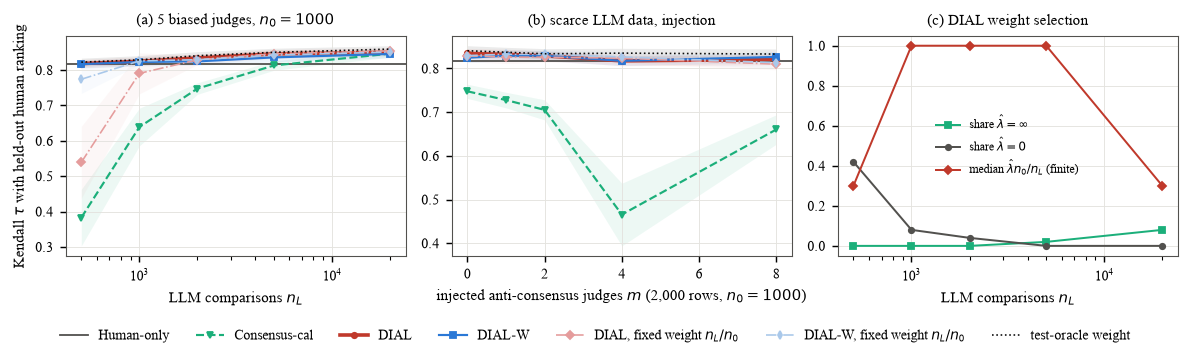

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(9.2, 2.5))
diag = ["human_only", "consensus_cal", "dial_mu", "dial_w", "dial_mle_mu", "dial_mle_w", "oracle_test"]
def tau_lines(ax, g, methods, label=True):
    for m in methods:
        gm = g[g.method == m].sort_values("level"); st = dict(STYLE[m]); lw = st.pop("lw", 1.2); mk = st.pop("marker", None)
        if gm.empty: continue
        if m == "human_only": ax.axhline(gm.ref_kendall_mean.mean(), color=st["color"], lw=1.0, label=LABEL[m] if label else None); continue
        ax.plot(gm.level, gm.ref_kendall_mean, lw=lw, marker=mk, ms=3, label=LABEL[m] if label else None, **st)
        ax.fill_between(gm.level, gm.ref_kendall_mean - 1.96 * gm.ref_kendall_se, gm.ref_kendall_mean + 1.96 * gm.ref_kendall_se, color=st["color"], alpha=0.08, lw=0)
if "arena_33k" in agg:
    a = agg["arena_33k"]
    tau_lines(axes[0], a[(a.sweep == "llm_budget") & (a.panel == "biased5") & (a.n_0_level == 1000)], diag)
    axes[0].set_xscale("log"); axes[0].set_xlabel("LLM comparisons $n_L$"); axes[0].set_ylabel("Kendall $\\tau$ with held-out human ranking"); axes[0].set_title("(a) 5 biased judges, $n_0=1000$", fontsize=8.5)
    tau_lines(axes[1], a[(a.sweep == "noise_scarce") & (a.panel == "biased5") & (a.kind == "anti")], diag, label=False)
    axes[1].set_xlabel("injected anti-consensus judges $m$ (2,000 rows, $n_0=1000$)"); axes[1].set_title("(b) scarce LLM data, injection", fontsize=8.5)
    g = a[(a.sweep == "llm_budget") & (a.panel == "biased5") & (a.n_0_level == 1000) & (a.method == "dial_mu")].sort_values("level")
    axes[2].plot(g.level, g.lam_inf_frac, marker="s", ms=3, lw=1.1, color=STYLE["consensus_cal"]["color"], label="share $\\hat\\lambda=\\infty$")
    axes[2].plot(g.level, g.lam_zero_frac, marker="o", ms=3, lw=1.1, color=STYLE["human_only"]["color"], label="share $\\hat\\lambda=0$")
    axes[2].plot(g.level, g.lam_rel_med.fillna(0), marker="D", ms=3, lw=1.1, color=STYLE["dial_mu"]["color"], label="median $\\hat\\lambda n_0/n_L$ (finite)")
    axes[2].set_xscale("log"); axes[2].set_xlabel("LLM comparisons $n_L$"); axes[2].set_title("(c) DIAL weight selection", fontsize=8.5); axes[2].legend(frameon=False, fontsize=6.5)
for ax in axes: ax.grid(True, color=GRID, lw=0.5)
h, l = axes[0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=7, frameon=False, bbox_to_anchor=(0.5, -0.1))
fig.tight_layout(); fig.savefig(FIGURES / "fig_real_diagnostics.pdf", bbox_inches="tight"); plt.show()

## Tables behind the figures

In [8]:
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
for d in agg:
    for (sw, pn, kd), g in agg[d].groupby(["sweep", "panel", "kind"]):
        piv = g.pivot_table(index=["level", "n_0_level"], columns="method", values="excess_mean").reindex(columns=list(PRESENTED) + ["dial_w", "staged_w", "dial_mle_mu", "dial_mle_w", "oracle_test", "dial_rsel"])
        print(f"=== {DLAB[d]} | {sw} | panel={pn} | kind={kd}  (excess held-out log loss, mean over {int(g.n.max())} seeds)"); print(piv.round(4).to_string()); print()

=== Chatbot Arena | budget | panel=all | kind=none  (excess held-out log loss, mean over 50 seeds)
method             human_only  pooled_cal  consensus_cal  dial_mu  dial_nodeb  dial_w  staged_w  dial_mle_mu  dial_mle_w  oracle_test  dial_rsel
level   n_0_level                                                                                                                               
-1.0    -1             0.0086      0.0087         0.0089   0.0081      0.0082  0.0087    0.0090       0.0088      0.0089       0.0075     0.0085
 50.0   -1             6.6515      0.0205         0.0207   0.0235      0.0238  0.0464    0.0443       0.0207      0.0472       0.0201     0.0679
 100.0  -1             1.0170      0.0162         0.0163   0.0165      0.0166  0.0283    0.0213       0.0163      0.0216       0.0156     0.0228
 200.0  -1             0.2220      0.0119         0.0121   0.0163      0.0164  0.0253    0.0146       0.0121      0.0148       0.0116     0.0163
 400.0  -1             0.0489  